# Day 3

In [58]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.data import Dataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Loading Data

In [59]:
iris = load_iris()
X = iris.data
Y = iris.target

In [60]:
x = pd.DataFrame(X)

print(x.info())
print()
y = pd.DataFrame(Y)
print(y.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None


##  Training, Testing Split & Scaling


In [61]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

### Sequential Keras Model
- A Keras Sequential model is a linear stack of neural network layers. It is the simplest way to build a deep learning model, where data flows in a strict, one-way sequence—entering the first layer, passing through each hidden layer one by one, and exiting through the final output layer.

In [62]:
model = keras.Sequential([
    layers.Dense(16,activation='relu',input_shape=(4,)),
    layers.Dense(8,activation='relu'),
    layers.Dense(6,activation='relu'),
    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- input layer is the one defined with input_shape 4
- first Layer with 8 neurons is the hidden layer
- second one with 6 neurons is the hidden layer
- third one with 3 neurons is the output layer
- > this is a basic simple sequential model.

In [63]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

- > model.summary
- shows the blueprint of the whole model.

In [64]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train,Y_train,epochs=50,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3646 - loss: 0.8662 - val_accuracy: 0.2083 - val_loss: 0.9910
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3854 - loss: 0.8335 - val_accuracy: 0.2500 - val_loss: 0.9653
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4062 - loss: 0.8053 - val_accuracy: 0.3333 - val_loss: 0.9441
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4688 - loss: 0.7811 - val_accuracy: 0.3750 - val_loss: 0.9275
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.7615 - val_accuracy: 0.4167 - val_loss: 0.9133
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5417 - loss: 0.7447 - val_accuracy: 0.4167 - val_loss: 0.9021
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6250 - loss: 0.7300 - val_accuracy: 0.4583 - val_loss: 0.8929
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6667 - loss: 0.7184 - val_accuracy: 0.5417 - val_loss: 0.8852


- > Compile
- Used Adam Optimizer - to adjust the weight after each epoch.
- Sparse Categorical CrossEntropy as the loss function - to measure how wrong the model predicting.
- Accuracy is used as the Matrix , that used to show after each epoch

- > Fit

- epoch - No of time model goes one complete pass through your entire dataset.

- batch_size - divided whole data into smaller chunks. Smaller chunks make learning faster and use less computer memory.

- validation_split -  Percent of data that of training data that is uesd to tests the model.

- verbose - tells Python to print out a live progress bar and stats on screen for every single epoch

## Model evaluvation

In [65]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9000 - loss: 0.4125
Test accuracy: 0.8999999761581421
Test loss: 0.4124775826931


## Plotting the Results

/tmp/ipykernel_4416/2988003575.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Train', 'Validation')


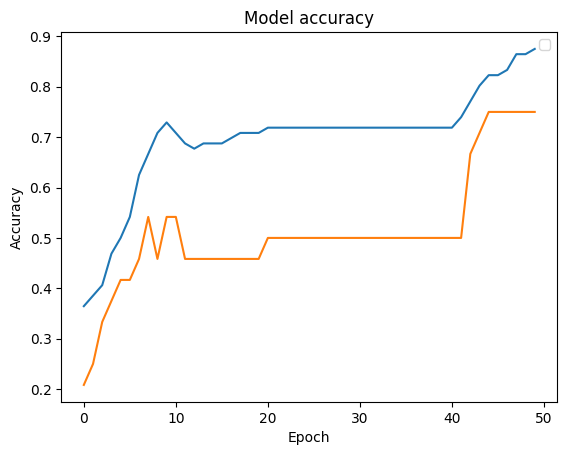

In [66]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend('Train', 'Validation')

#Diabetes

- New Dataset.

In [67]:
df = pd.read_excel('diabetes.xlsx')
df.head()

,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,DietType,Outcome
0,148,72,33.6,0.63,50,1,1
1,85,66,26.6,0.35,31,2,0
2,183,64,23.3,0.67,32,1,1
3,89,66,28.1,0.17,21,1,0
4,137,40,43.1,2.29,33,1,1


In [68]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [70]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [71]:
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [73]:
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6986 - loss: 0.6189 - val_accuracy: 0.6667 - val_loss: 0.6181
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7108 - loss: 0.5986 - val_accuracy: 0.6423 - val_loss: 0.6020
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7169 - loss: 0.5803 - val_accuracy: 0.6585 - val_loss: 0.5848
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7271 - loss: 0.5620 - val_accuracy: 0.6504 - val_loss: 0.5655
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7291 - loss: 0.5441 - val_accuracy: 0.6748 - val_loss: 0.5473
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7454 - loss: 0.5256 - val_accuracy: 0.7236 - val_loss: 0.5274
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7760 - loss: 0.5078 - val_accuracy: 0.7317 - val_loss: 0.5039
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7984 - loss: 0.4888 - val_accuracy: 0.7480 - 

In [74]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8312 - loss: 0.3824
Test accuracy: 0.8311688303947449
Test loss: 0.3823806941509247


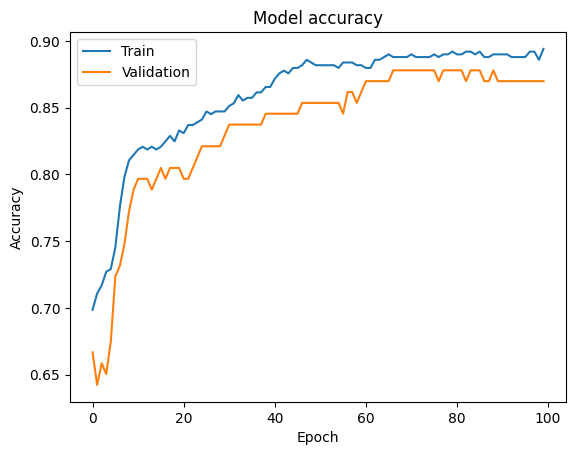

In [75]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

# Titianic

In [76]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

In [77]:
import seaborn as sns
df = sns.load_dataset('titanic')
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [78]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features]
y = df['survived']

## Pipelining is used here.

In [79]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

Numerical and Categorical pipelines.

In [80]:
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked']

numerical and categorical features divided.

In [81]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [82]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [84]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [85]:
base_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
base_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [87]:
history_baseline = base_model.fit(X_train, y_train,validation_split=0.2, epochs=50,batch_size=32,verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3814 - loss: 0.7600 - val_accuracy: 0.3916 - val_loss: 0.6850
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5905 - loss: 0.6603 - val_accuracy: 0.6993 - val_loss: 0.6209
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7733 - loss: 0.5988 - val_accuracy: 0.7762 - val_loss: 0.5804
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7979 - loss: 0.5612 - val_accuracy: 0.7762 - val_loss: 0.5475
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8049 - loss: 0.5291 - val_accuracy: 0.7972 - val_loss: 0.5205
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8120 - loss: 0.4997 - val_accuracy: 0.7972 - val_loss: 0.4960
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8207 - loss: 0.4720 - val_accuracy: 0.8042 - val_loss: 0.4759
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8260 - loss: 0.4480 - val_accuracy: 0.7902 - val_los

In [88]:
base_loss, base_acc = base_model.evaluate(X_test, y_test)

print("Base model Accuracy:", base_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7989 - loss: 0.4404 
Base model Accuracy: 0.7988826632499695


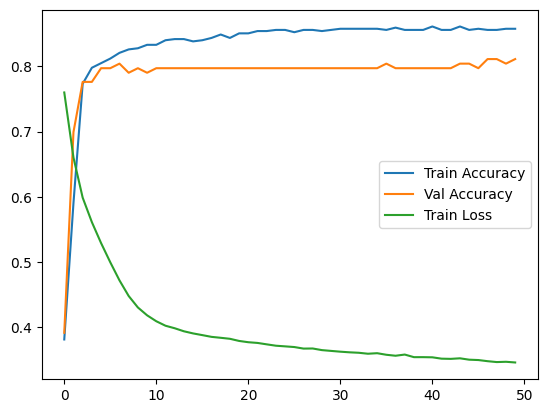

In [89]:
import matplotlib.pyplot as plt

plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.legend()
plt.show()

## Model Comparison

In [90]:
def create_model(optimizer):

    model = keras.Sequential([
        layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [91]:
small_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.0001)
)

history_small_lr = small_lr_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6292 - loss: 0.6366 - val_accuracy: 0.6014 - val_loss: 0.6430
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6292 - loss: 0.6321 - val_accuracy: 0.6014 - val_loss: 0.6383
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6292 - loss: 0.6276 - val_accuracy: 0.6084 - val_loss: 0.6339
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6327 - loss: 0.6235 - val_accuracy: 0.6154 - val_loss: 0.6291
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6397 - loss: 0.6191 - val_accuracy: 0.6154 - val_loss: 0.6248
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6397 - loss: 0.6152 - val_accuracy: 0.6154 - val_loss: 0.6202
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6415 - loss: 0.6110 - val_accuracy: 0.6154 - val_loss: 0.6160
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6432 - loss: 0.6068 - val_accuracy: 0.6154 - val_loss

In [92]:
medium_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.001)
)
history_medium_lr = medium_lr_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6221 - loss: 0.6592 - val_accuracy: 0.5944 - val_loss: 0.6519
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6239 - loss: 0.6085 - val_accuracy: 0.6014 - val_loss: 0.6102
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6591 - loss: 0.5722 - val_accuracy: 0.6993 - val_loss: 0.5764
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7364 - loss: 0.5406 - val_accuracy: 0.7483 - val_loss: 0.5469
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7891 - loss: 0.5124 - val_accuracy: 0.7692 - val_loss: 0.5200
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8172 - loss: 0.4862 - val_accuracy: 0.7902 - val_loss: 0.4964
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8225 - loss: 0.4630 - val_accuracy: 0.7902 - val_loss: 0.4752
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8330 - loss: 0.4410 - val_accuracy: 0.7902 - val_loss

In [93]:
large_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.01)
)
history_large_lr = large_lr_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7047 - loss: 0.5648 - val_accuracy: 0.7692 - val_loss: 0.4805
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8243 - loss: 0.4586 - val_accuracy: 0.8182 - val_loss: 0.4538
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8383 - loss: 0.4231 - val_accuracy: 0.8042 - val_loss: 0.4565
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8418 - loss: 0.3976 - val_accuracy: 0.7902 - val_loss: 0.4830
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8436 - loss: 0.3806 - val_accuracy: 0.8042 - val_loss: 0.4784
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8541 - loss: 0.3736 - val_accuracy: 0.7972 - val_loss: 0.4800
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8576 - loss: 0.3656 - val_accuracy: 0.7972 - val_loss: 0.4938
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8506 - loss: 0.3683 - val_accuracy: 0.8042 - val_loss

In [94]:
# Evaluate models on the test set
loss_small_lr, acc_small_lr = small_lr_model.evaluate(X_test, y_test, verbose=0)
loss_medium_lr, acc_medium_lr = medium_lr_model.evaluate(X_test, y_test, verbose=0)
loss_large_lr, acc_large_lr = large_lr_model.evaluate(X_test, y_test, verbose=0)

print("Small LR Model Test Accuracy:",round(acc_small_lr,4))
print("Medium LR Model Test Accuracy:",round(acc_medium_lr,4))
print("Large LR Model Test Accuracy:",round(acc_large_lr,4))

Small LR Model Test Accuracy: 0.7765
Medium LR Model Test Accuracy: 0.7821
Large LR Model Test Accuracy: 0.7821


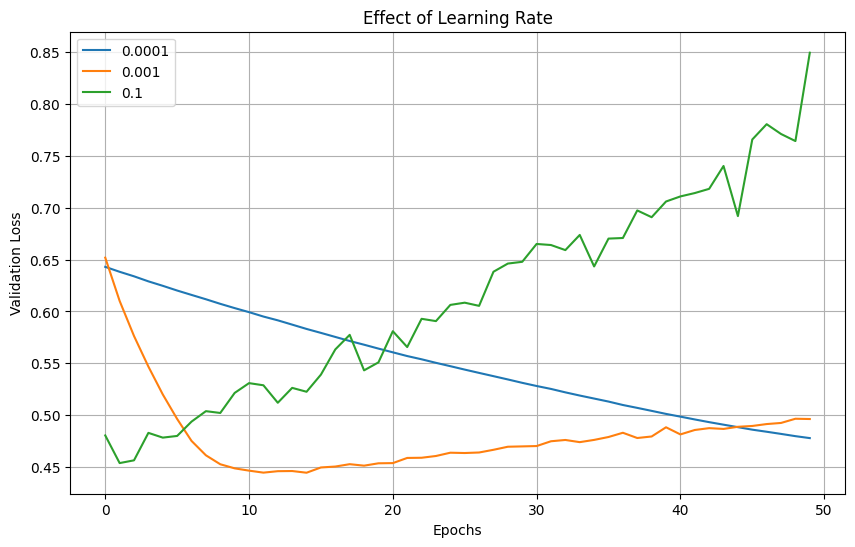

In [95]:
plt.figure(figsize=(10,6))

plt.plot(
    history_small_lr.history['val_loss'],
    label='0.0001'
)
plt.plot(
    history_medium_lr.history['val_loss'],
    label='0.001'
)
plt.plot(
    history_large_lr.history['val_loss'],
    label='0.1'
)

plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Effect of Learning Rate')
plt.legend()
plt.grid(True)

plt.show()

### Plotting Training History for All Models

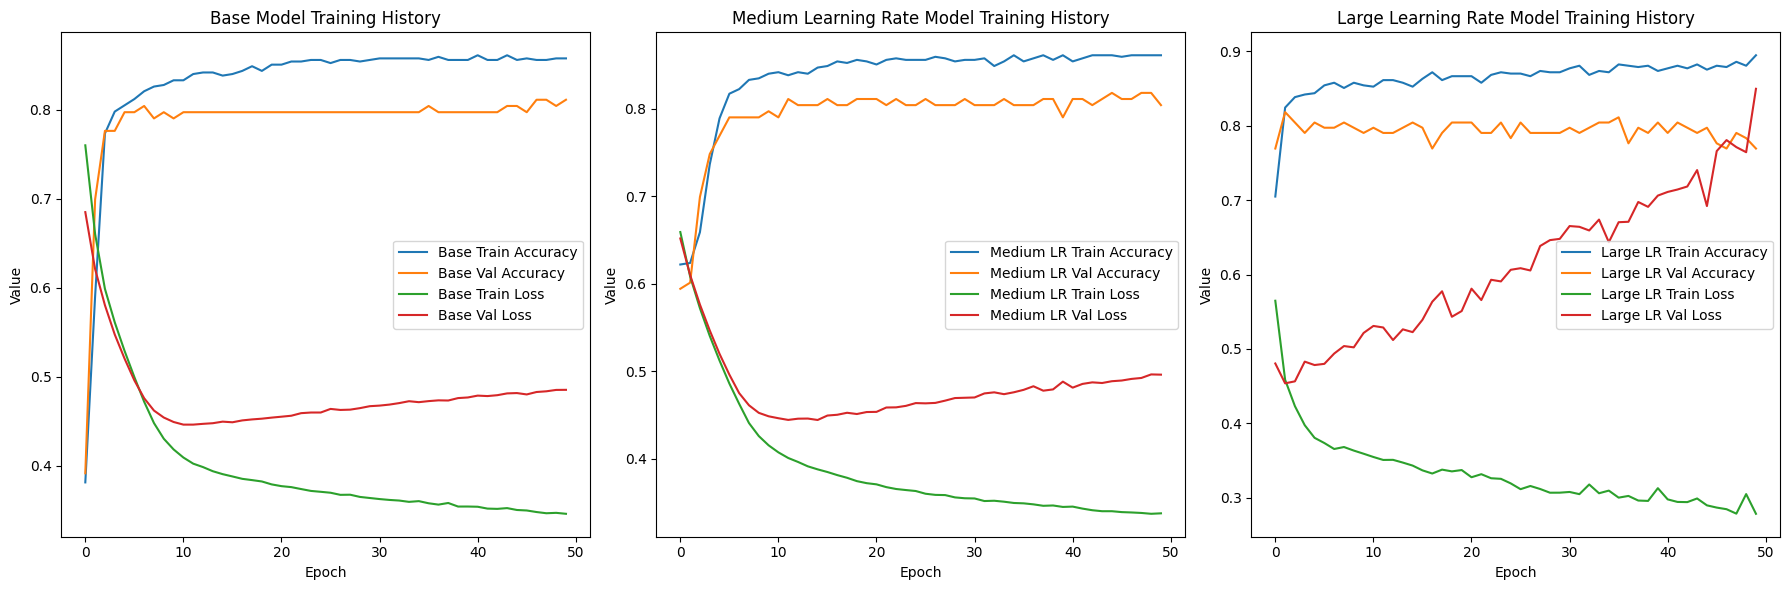

In [96]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(history_baseline.history['accuracy'], label='Base Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Base Val Accuracy')
plt.plot(history_baseline.history['loss'], label='Base Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Base Val Loss')
plt.title('Base Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_medium_lr.history['accuracy'], label='Medium LR Train Accuracy')
plt.plot(history_medium_lr.history['val_accuracy'], label='Medium LR Val Accuracy')
plt.plot(history_medium_lr.history['loss'], label='Medium LR Train Loss')
plt.plot(history_medium_lr.history['val_loss'], label='Medium LR Val Loss')
plt.title('Medium Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_large_lr.history['accuracy'], label='Large LR Train Accuracy')
plt.plot(history_large_lr.history['val_accuracy'], label='Large LR Val Accuracy')
plt.plot(history_large_lr.history['loss'], label='Large LR Train Loss')
plt.plot(history_large_lr.history['val_loss'], label='Large LR Val Loss')
plt.title('Large Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

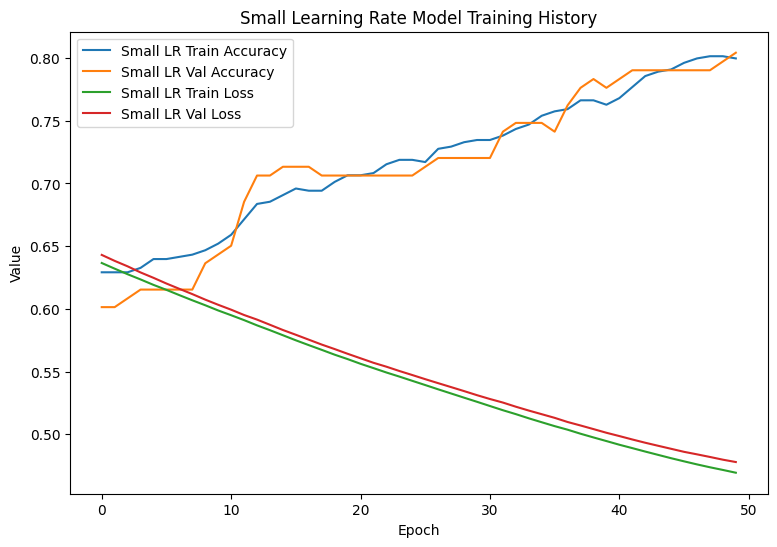

In [97]:
plt.figure(figsize=(9, 6))
plt.plot(history_small_lr.history['accuracy'], label='Small LR Train Accuracy')
plt.plot(history_small_lr.history['val_accuracy'], label='Small LR Val Accuracy')
plt.plot(history_small_lr.history['loss'], label='Small LR Train Loss')
plt.plot(history_small_lr.history['val_loss'], label='Small LR Val Loss')
plt.title('Small Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
# plt.tight_layout()
plt.show()

##Dropout model

In [98]:
drop_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [99]:
drop_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [100]:
history_dropout = drop_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5870 - loss: 0.6893 - val_accuracy: 0.7203 - val_loss: 0.6067
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7223 - loss: 0.5947 - val_accuracy: 0.7273 - val_loss: 0.5699
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7557 - loss: 0.5520 - val_accuracy: 0.7762 - val_loss: 0.5294
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7504 - loss: 0.5249 - val_accuracy: 0.7762 - val_loss: 0.4972
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7715 - loss: 0.5063 - val_accuracy: 0.7972 - val_loss: 0.4770
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7786 - loss: 0.4872 - val_accuracy: 0.8112 - val_loss: 0.4624
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7856 - loss: 0.4619 - val_accuracy: 0.8182 - val_loss: 0.4512
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7803 - loss: 0.4763 - val_accuracy: 0.8252 - val_

In [101]:
drop_loss,drop_accuracy = drop_model.evaluate(X_test, y_test)
print(f"Dropout Model Accuracy: {drop_accuracy}")
print(f"Dropout Model Loss: {drop_loss}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8045 - loss: 0.4423 
Dropout Model Accuracy: 0.8044692873954773
Dropout Model Loss: 0.4423065185546875


## Early Stoping in this drop_model

In [102]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [103]:
history = drop_model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8506 - loss: 0.3702 - val_accuracy: 0.8112 - val_loss: 0.4911
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8559 - loss: 0.3697 - val_accuracy: 0.8112 - val_loss: 0.4917
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8559 - loss: 0.3520 - val_accuracy: 0.8112 - val_loss: 0.4898
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8559 - loss: 0.3623 - val_accuracy: 0.8042 - val_loss: 0.4875
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8471 - loss: 0.3669 - val_accuracy: 0.8042 - val_loss: 0.4873
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8576 - loss: 0.3646 - val_accuracy: 0.8112 - val_loss: 0.4852
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8489 - loss: 0.3646 - val_accuracy: 0.8182 - val_loss: 0.4886
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8559 - loss: 0.3853 - val_accuracy: 0.8112 - v

In [104]:
drop_loss,drop_accuracy = drop_model.evaluate(X_test, y_test)
print(f"Dropout Model Accuracy: {drop_accuracy}")
print(f"Dropout Model Loss: {drop_loss}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7989 - loss: 0.4467 
Dropout Model Accuracy: 0.7988826632499695
Dropout Model Loss: 0.44672244787216187


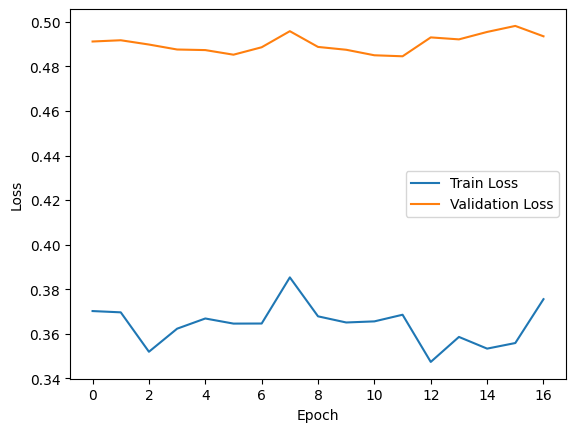

In [105]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

If performance of model is low :


1. Early Stoping
2. Dropout Method
3. L1,L2 Regularlization

Learned about creating sequrntial models using keras.sequrntial, used different datasets on the models and compared different models based on different learning rates and plotted different graphs of these models.